In [1]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('train.csv' , usecols= [ 'Age' , 'Fare' , 'Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
x = df.drop(columns=['Survived'])
y = df['Survived']
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state=2)

In [8]:
x_train['Age_Imputed'] = x_train['Age']
x_test['Age_Imputed'] = x_test['Age']

In [10]:
x_train.head()

,Age,Fare,Age_Imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [11]:
x_train['Age_Imputed'][x_train['Age_Imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['Age_Imputed'][x_test['Age_Imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_20916\1673694197.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_Imputed'][x_train['Age_Imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).

In [12]:
x_train.head()

,Age,Fare,Age_Imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [ ]:
x_train.isnull().sum() #we handle the missing values in age imputed column by filling it with random values of age column

Age            148
Fare             0
Age_Imputed      0
dtype: int64

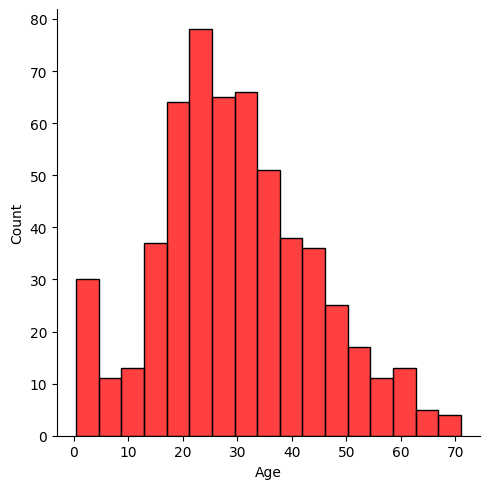

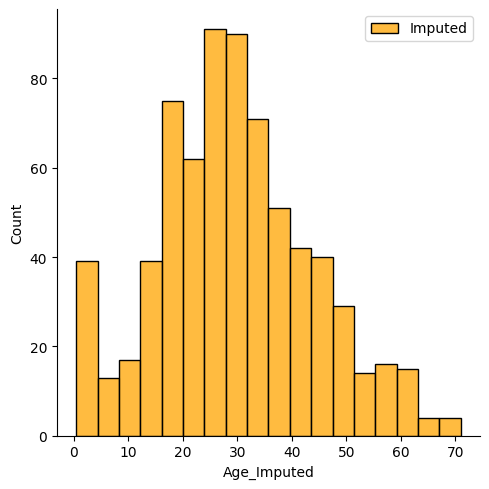

In [18]:
sns.displot(x_train['Age'] , label ='Orignal' , color= 'red')
sns.displot(x_train['Age_Imputed'] , label ='Imputed' , color='orange' )
plt.legend()
plt.show()

In [ ]:
print('Orignal data Variance : ' , x_train['Age'].var())
print('Imputed data Variance : ' , x_train['Age_Imputed'].var())
#so we can see that the variance of both column were not to difference because of random imputation

Orignal data Variance :  204.34951339046142
Imputed data Variance :  201.86040914975743


In [20]:
x_train[['Age' , 'Fare' , 'Age_Imputed']].cov()

,Age,Fare,Age_Imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,78.733333
Age_Imputed,204.349513,78.733333,201.860409


<Axes: >

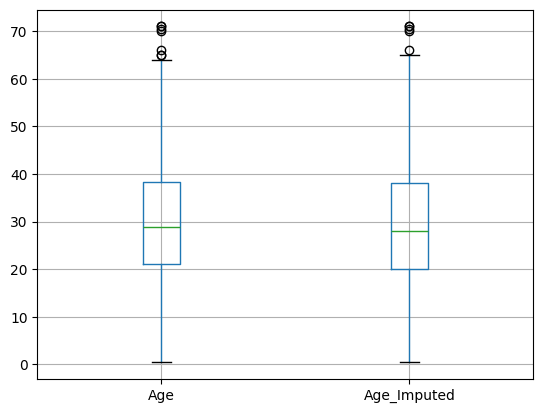

In [21]:
x_train[['Age' , 'Age_Imputed']].boxplot()

# Imputing Categorical Data

In [27]:
data= pd.read_csv('housing.csv' , usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [28]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [29]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [31]:
x1 = data
y1 = data['SalePrice']

In [32]:
x_train1 , x_test1 , y_train1 , y_test1 = train_test_split(x1 , y1 , test_size=0.2 , random_state=2)

In [33]:
x_train1['GarageQual_Imputed'] = x_train1['GarageQual']
x_test1['GarageQual_Imputed'] = x_test1['GarageQual']

x_train1['FireplaceQu_Imputed'] = x_train1['FireplaceQu']
x_test1['FireplaceQu_Imputed'] = x_test1['FireplaceQu']

In [34]:
x_train1

,FireplaceQu,GarageQual,SalePrice,GarageQual_Imputed,FireplaceQu_Imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [ ]:
x_train1['GarageQual_Imputed'][x_train1['GarageQual_Imputed'].isnull()] = x_train1['GarageQual'].dropna().sample(x_train1['GarageQual'].isnull().sum()).values
x_test1['GarageQual_Imputed'][x_test1['GarageQual_Imputed'].isnull()] = x_test1['GarageQual'].dropna().sample(x_test1['GarageQual'].isnull().sum()).values

C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_20916\3160169042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train1['GarageQual_Imputed'][x_train1['GarageQual_Imputed'].isnull()] = x_train1['GarageQual'].dropna().sample(x_train1['GarageQual'].isnull().sum()).values
C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_20916\3160169042.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a co

In [37]:
x_train1['FireplaceQu_Imputed'][x_train1['FireplaceQu_Imputed'].isnull()] = x_train1['FireplaceQu'].dropna().sample(x_train1['FireplaceQu'].isnull().sum()).values
x_test1['FireplaceQu_Imputed'][x_test1['FireplaceQu_Imputed'].isnull()] = x_test1['FireplaceQu'].dropna().sample(x_test1['FireplaceQu'].isnull().sum()).values

C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_20916\3918612937.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train1['FireplaceQu_Imputed'][x_train1['FireplaceQu_Imputed'].isnull()] = x_train1['FireplaceQu'].dropna().sample(x_tr

In [ ]:
x_train1.isnull().sum() 

FireplaceQu            557
GarageQual              65
SalePrice                0
GarageQual_Imputed       0
FireplaceQu_Imputed      0
dtype: int64

In [41]:
temp = pd.concat(
    [
        x_train1['GarageQual'].value_counts()/len(x_train1['GarageQual'].dropna()),
        x_train1['GarageQual_Imputed'].value_counts()/len(x_train1)
    ],
    axis=1)
temp.columns = ['Orignal' , 'Imputed']

In [42]:
temp

,Orignal,Imputed
TA,0.951043,0.953767
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [43]:
temp1 = pd.concat(
    [
        x_train1['FireplaceQu'].value_counts() / len(x_train1['FireplaceQu'].dropna()),
        x_train1['FireplaceQu_Imputed'].value_counts() / len(x_train1)
    ],
    axis=1)
temp1.columns = ['Orignal' , 'Imputed']

In [44]:
temp1

,Orignal,Imputed
Gd,0.494272,0.495719
TA,0.412439,0.412671
Fa,0.040917,0.042808
Po,0.027823,0.026541
Ex,0.024550,0.022260


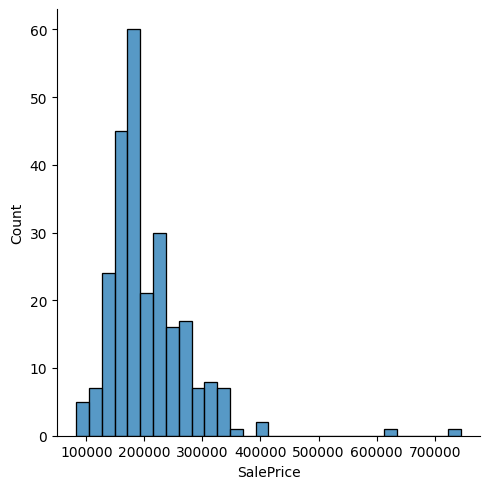

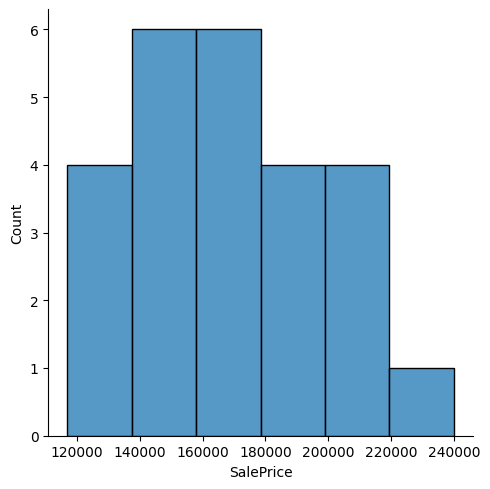

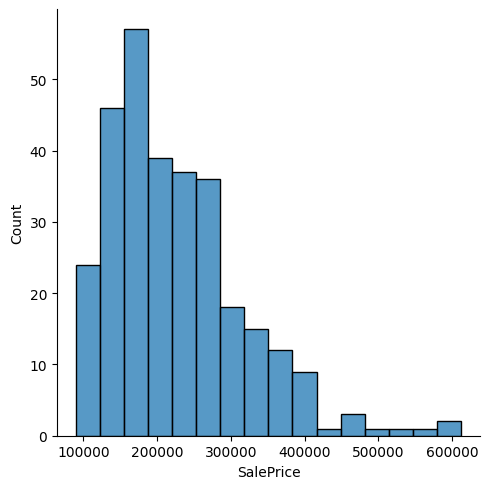

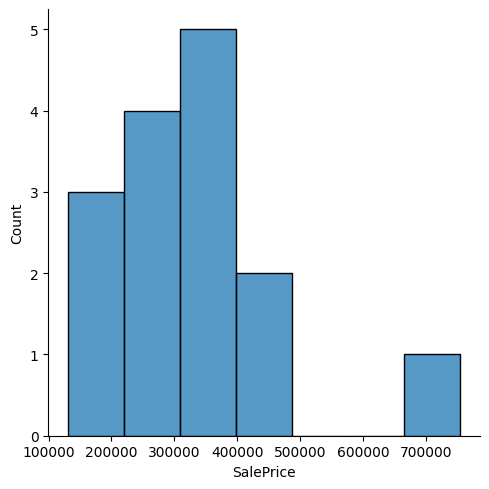

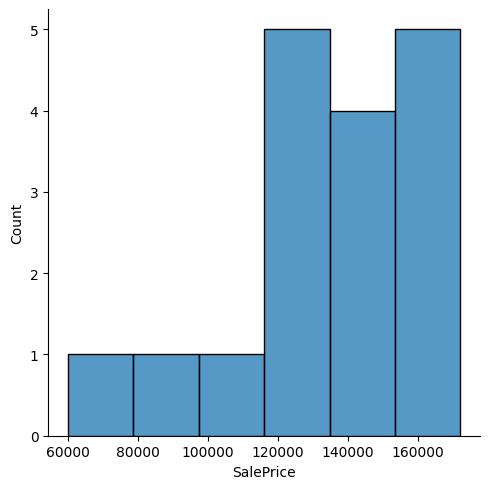

In [45]:
for category in x_train1['FireplaceQu'].dropna().unique():
    sns.displot(x_train1[x_train1['FireplaceQu'] == category]['SalePrice'] , label = category)
plt.show()

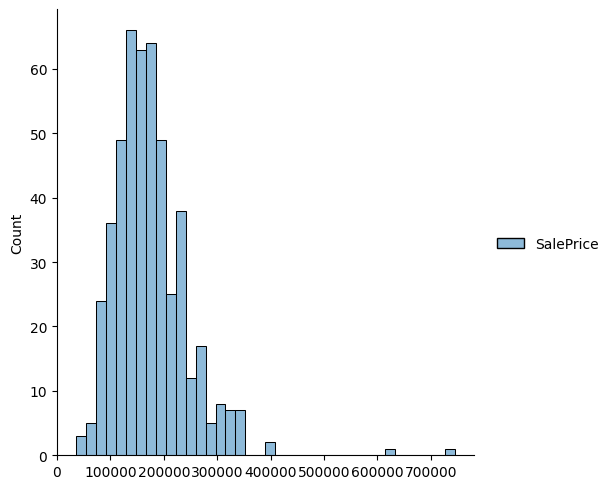

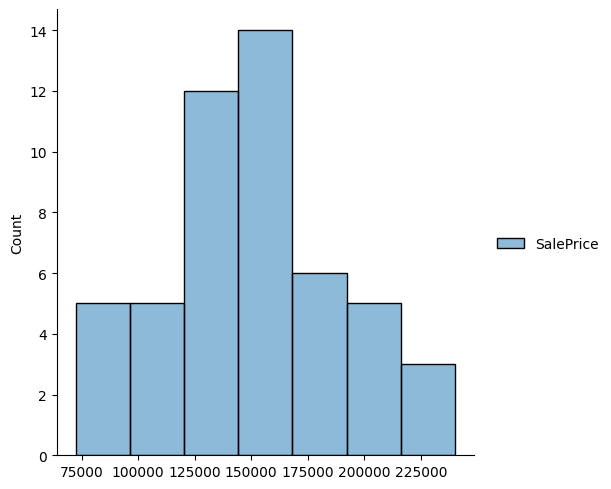

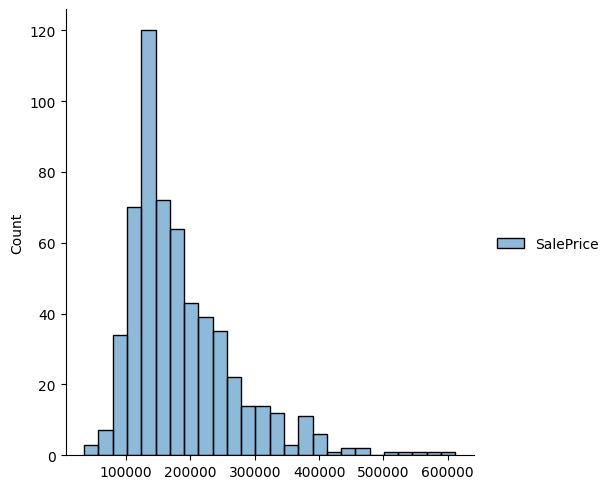

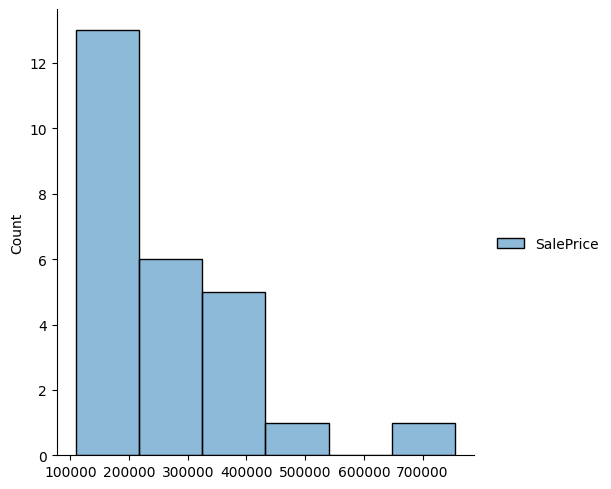

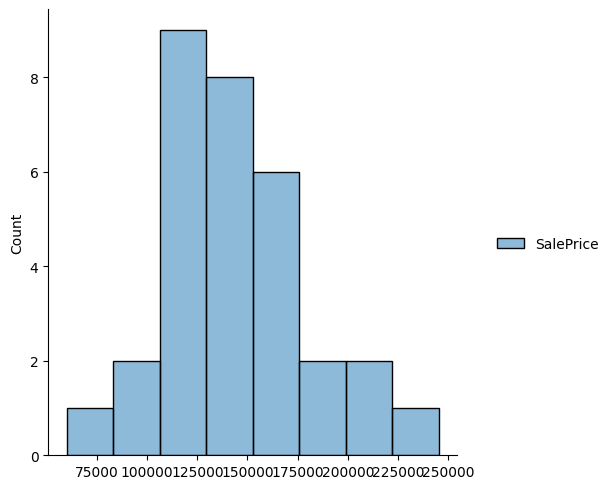

In [ ]:
for category in x_train1['FireplaceQu'].dropna().unique():
    sns.displot(x_train1[x_train1['FireplaceQu_Imputed']==category] ,  label = category)
plt.show()    

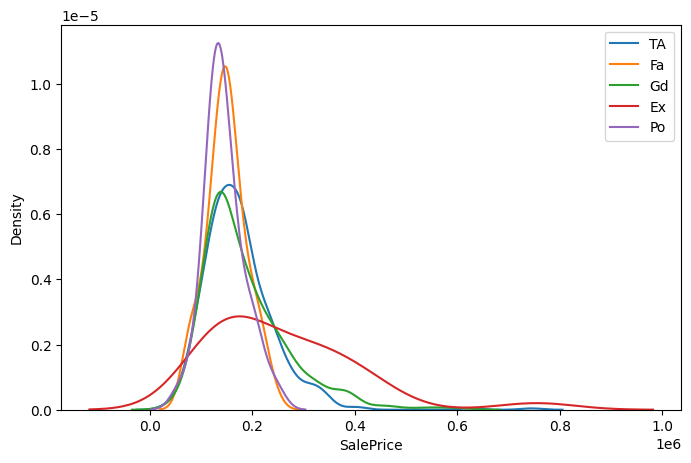

In [50]:
plt.figure(figsize=(8,5))

for category in x_train1['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        x_train1[x_train1['FireplaceQu_Imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.show()


C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_20916\1382314001.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Arjun Kaushik\AppData\Local\Temp\ipykernel_20916\1382314001.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


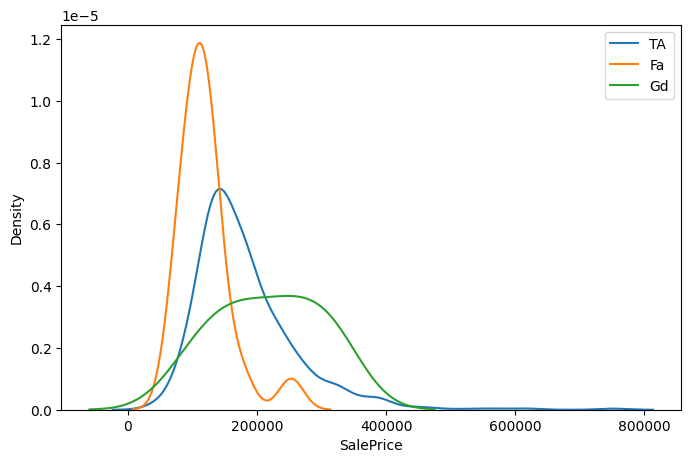

In [51]:
plt.figure(figsize=(8,5))

for category in x_train1['GarageQual'].dropna().unique():
    sns.kdeplot(
        x_train1[x_train1['GarageQual_Imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.show()
